This notebook is about LightGBM, a gradient boosting framework that uses tree based learning algorithms. 

-------------------------------------------------------------------

It is designed to be distributed and efficient with the following advantages:
1. Faster training speed and higher efficiency.
2. Lower memory usage.
3. Better accuracy.
4. Support of parallel and GPU learning.


You can use LightGBM for regression, classification and ranking tasks.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [64]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


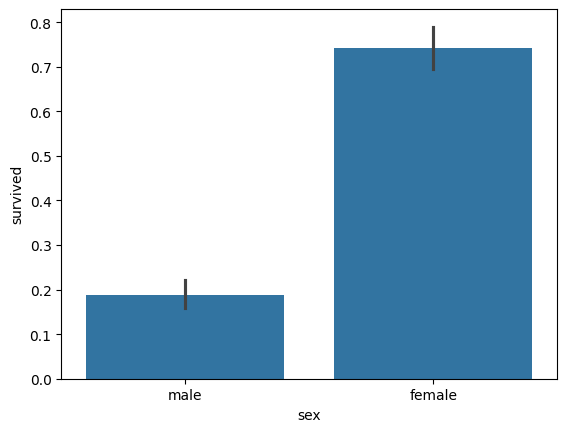

In [66]:
sns.barplot(data=df,x='sex',y='survived')
plt.show()

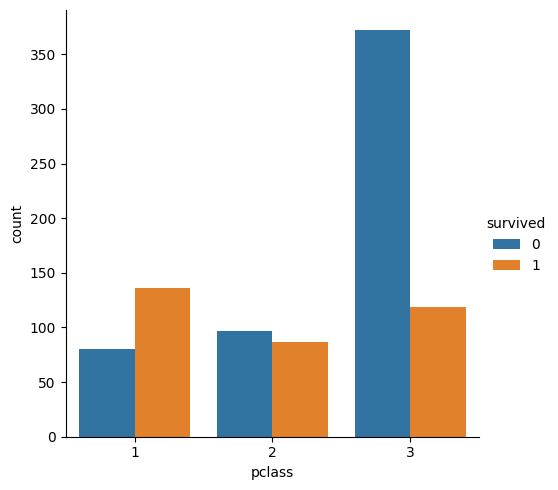

In [67]:
sns.catplot(data=df,x='pclass',hue="survived",kind='count')
plt.show()

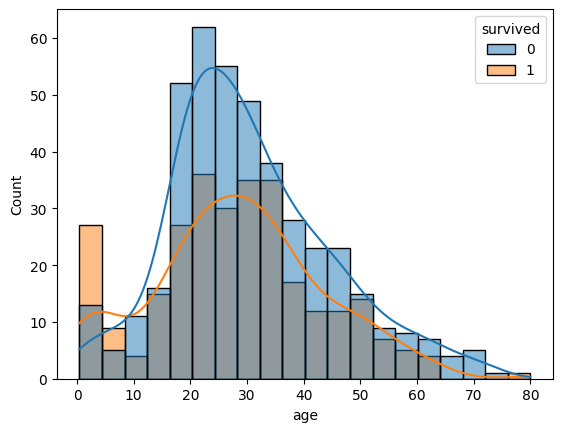

In [68]:
sns.histplot(data=df,x='age',hue='survived',kde=True)
plt.show()

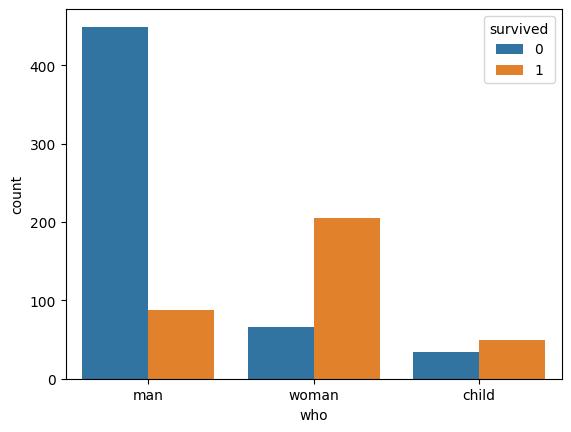

In [69]:
sns.countplot(x='who',data=df,hue='survived')
plt.show()

In [70]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [71]:
df.drop(columns=['deck','embark_town','alive'],axis=1,inplace=True)

In [72]:
df.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [73]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [74]:
df["age"]=df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [75]:
df.isnull().sum()    

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [76]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [77]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [78]:
df["embarked"].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [79]:
df["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [80]:
df["adult_male"].value_counts()

adult_male
True     537
False    354
Name: count, dtype: int64

In [81]:
df["alone"].value_counts()

alone
True     537
False    354
Name: count, dtype: int64

In [82]:
df["adult_male"]=df["adult_male"].astype(int)
df["alone"]=df["alone"].astype(int)

In [83]:
X=df.drop(columns=['survived'],axis=1) 
y=df['survived']

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=34)

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [86]:
categorical_features=['sex','class','embarked','who']
transformer=ColumnTransformer(transformers=[('one_hot',OneHotEncoder(drop="first",handle_unknown="ignore"),categorical_features)],remainder='passthrough')
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

In [87]:
encoded_cols=transformer.get_feature_names_out()
X_train_encoded=pd.DataFrame(X_train,columns=encoded_cols)
X_test_encoded=pd.DataFrame(X_test,columns=encoded_cols)

In [88]:
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
import lightgbm as lgb  
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model=lgb.LGBMClassifier(verbosity=-1) #verbosity=-1 to suppress warnings
model.fit(X_train_encoded,y_train)
y_pred=model.predict(X_test_encoded)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.8251121076233184
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       138
           1       0.79      0.73      0.76        85

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.83      0.82       223

Confusion Matrix:
 [[122  16]
 [ 23  62]]


In [90]:
importance=model.feature_importances_
feature_names=X_train_encoded.columns
feature_importance_df=pd.DataFrame(
    {
        'Feature':feature_names,
        'Importance':importance
    }
)

In [91]:
feature_importance_df.sort_values(by='Importance',ascending=False)

,Feature,Importance
11,remainder__fare,1147
8,remainder__age,904
10,remainder__parch,73
4,one_hot__embarked_S,72
2,one_hot__class_Third,57
9,remainder__sibsp,55
5,one_hot__who_man,39
6,one_hot__who_woman,38
1,one_hot__class_Second,28
0,one_hot__sex_male,27


In [92]:
#hyperparameter tuning 

from sklearn.model_selection import RandomizedSearchCV
lgb_model=lgb.LGBMClassifier(verbosity=-1)
param_dist={
    'num_leaves':[15,31,64,127],
    'learning_rate':[0.01,0.05,0.1,0.3],
    'n_estimators':[100,300,500],
    'max_depth':[3,5,7,-1],
    'min_child_samples':[10,20,30],
    'subsample':[0.6,0.8,1.0],  
    'colsample_bytree':[0.6,0.8,1.0]
}

In [93]:
random_search=RandomizedSearchCV(estimator=lgb_model,param_distributions=param_dist,n_iter=50,scoring='accuracy',cv=5,verbose=1,random_state=34)    

In [94]:
random_search.fit(X_train_encoded,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [95]:
random_search.best_params_

{'subsample': 0.8,
 'num_leaves': 31,
 'n_estimators': 300,
 'min_child_samples': 20,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [96]:
y_pred_tuned=random_search.predict(X_test_encoded)
print("Tuned Accuracy:",accuracy_score(y_test,y_pred_tuned))
print("Tuned Classification Report:\n",classification_report(y_test,y_pred_tuned))
print("Tuned Confusion Matrix:\n",confusion_matrix(y_test,y_pred_tuned))

Tuned Accuracy: 0.8385650224215246
Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       138
           1       0.80      0.76      0.78        85

    accuracy                           0.84       223
   macro avg       0.83      0.82      0.83       223
weighted avg       0.84      0.84      0.84       223

Tuned Confusion Matrix:
 [[122  16]
 [ 20  65]]


In [97]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(use_label_encoder=False,eval_metric='logloss')
xgb_model.fit(X_train_encoded,y_train)
y_pred_xgb=xgb_model.predict(X_test_encoded)
print("XGBoost Accuracy:",accuracy_score(y_test,y_pred_xgb))
print("XGBoost Classification Report:\n",classification_report(y_test,y_pred_xgb))
print("XGBoost Confusion Matrix:\n",confusion_matrix(y_test,y_pred_xgb))

XGBoost Accuracy: 0.8251121076233184
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86       138
           1       0.81      0.71      0.75        85

    accuracy                           0.83       223
   macro avg       0.82      0.80      0.81       223
weighted avg       0.82      0.83      0.82       223

XGBoost Confusion Matrix:
 [[124  14]
 [ 25  60]]


c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:20:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [98]:
param_dist_xgboost={
    'learning_rate':[0.01,0.05,0.1,0.3],
    'n_estimators':[100,300,500],
    'max_depth':[3,5,7,-1],  
    'colsample_bytree':[0.6,0.8,1.0]
}

In [99]:
random_search2=RandomizedSearchCV(estimator=XGBClassifier(),param_distributions=param_dist_xgboost,n_iter=50,scoring='accuracy',cv=5,verbose=2,random_state=34)
random_search2.fit(X_train_encoded,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, n_estimators=500; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, n_estimators=500; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, n_estimators=500; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, n_estimators=500; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, n_estimators=500; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100; total time=   0.0s
[CV] END colsample_bytre

c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
60 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packa

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [100]:
y_pred2=random_search2.predict(X_test_encoded)
print("Tuned XGBoost Accuracy:",accuracy_score(y_test,y_pred2))
print("Tuned XGBoost Classification Report:\n",classification_report(y_test,y_pred2))
print("Tuned XGBoost Confusion Matrix:\n",confusion_matrix(y_test,y_pred2))

Tuned XGBoost Accuracy: 0.8295964125560538
Tuned XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87       138
           1       0.81      0.73      0.77        85

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.82       223
weighted avg       0.83      0.83      0.83       223

Tuned XGBoost Confusion Matrix:
 [[123  15]
 [ 23  62]]
